# KPIs

## Librerias

In [6]:
import pandas as pd 
import matplotlib.pyplot as plt

## Carga de datos

In [7]:
data_path = "../Data/Silver_BANK_marketing_190126.csv"

In [8]:
# Cargar el dataset con separador y encoding correctos
df = pd.read_csv(
    data_path,
    sep=",",
    encoding="utf-8"
)

In [9]:
df.head()

,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,2,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
2,3,56.0,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
3,4,41.0,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
4,5,55.0,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10643 entries, 0 to 10642
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10643 non-null  int64  
 1   age             10634 non-null  float64
 2   job             10643 non-null  object 
 3   marital         10643 non-null  object 
 4   education       10643 non-null  object 
 5   credit_default  10643 non-null  int64  
 6   balance         10643 non-null  int64  
 7   housing         10643 non-null  int64  
 8   loan            10643 non-null  int64  
 9   contact         10643 non-null  object 
 10  day             10643 non-null  int64  
 11  month           10643 non-null  object 
 12  duration        10643 non-null  int64  
 13  campaign        10643 non-null  int64  
 14  pdays           10643 non-null  int64  
 15  previous        10643 non-null  int64  
 16  poutcome        10643 non-null  object 
 17  deposit         10643 non-null 

## Cálculo de KPIs

### 1. Porcentaje de Conversión a Depósito

In [11]:
# total de clientes contactados
total_clients = df.shape[0]

# número de clientes que suscribieron depósito
total_deposits = df['deposit'].sum()

# porcentaje de conversión
conversion = (total_deposits / total_clients) * 100

conversion

np.float64(49.70403081837828)

### 2. Promedio de Duración de Llamadas de Suscriptores

In [12]:
# filtrar solo los clientes que suscribieron
subscribers = df[df['deposit'] == 1]

# suma de duración de llamadas
sum_duration = subscribers['duration'].sum()

# número de suscriptores
num_subscribers = subscribers.shape[0]

# promedio
avg_duration = sum_duration / num_subscribers

# conversión a minutos y segundos
minutes = int(avg_duration // 60)
seconds = int(avg_duration % 60)

avg_duration_f = (f"{minutes} min {seconds} s")

### 3. Porcentaje de Llamadas a Teléfono o Móvil

In [13]:
# total de contactos durante la campaña 
total_contacts = df['campaign'].sum()

# llamadas realizadas por teléfono o móvil
total_calls = df.loc[df['contact'].isin(['telephone', 'cellular']), 'campaign'].sum()

# porcentaje
pct_calls = (total_calls / total_contacts) * 100

pct_calls

np.float64(77.26331639375118)

### 4. Promedio de Contactos previos de Suscriptores

In [14]:
# filtrar solo suscriptores
subscribers = df[df['deposit'] == 1]

# promedio de contactos previos
avg_prev_contacts = subscribers['previous'].mean()

avg_prev_contacts

np.float64(1.170132325141777)

### 5. Mes con Mayor Tasa de Conversión

In [15]:
# Tasa de conversión por mes
conversion_month = (
    df.groupby('month')['deposit']
      .mean()
      .mul(100)
      .round(2)
)

# Mes con mayor tasa de conversión
top_month = conversion_month.idxmax()
top_conversion_rate = conversion_month.max()

# Mostrar resultados
print("Tasa de conversión por mes:")
print(conversion_month.to_string())

print("\nMes con mayor tasa de conversión:")
print(f"- Mes: {top_month}")
print(f"- Tasa de conversión: {top_conversion_rate}%")

Tasa de conversión por mes:
month
apr    64.98
aug    47.45
dec    91.74
feb    59.12
jan    43.43
jul    43.88
jun    46.51
mar    90.51
may    34.98
nov    44.88
oct    83.46
sep    85.67

Mes con mayor tasa de conversión:
- Mes: dec
- Tasa de conversión: 91.74%


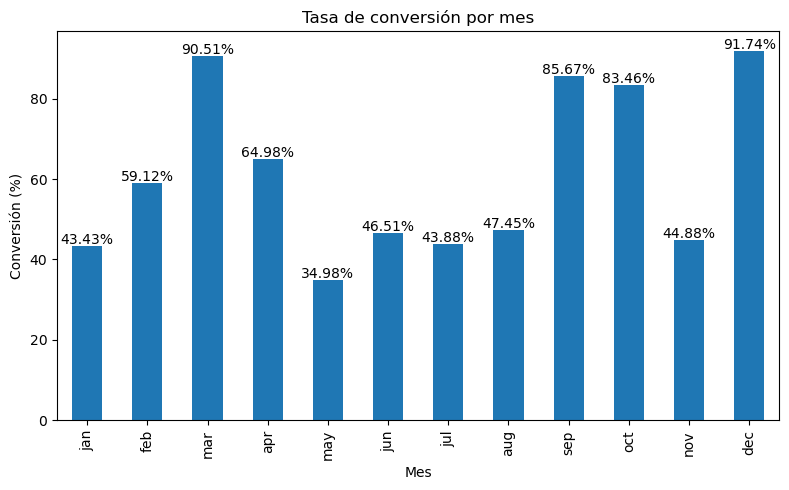

In [16]:
# Gráfica por meses

# Orden cronológico de meses
orden_meses = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]

# Reindexar según el orden natural
conversion_month = conversion_month.reindex(orden_meses)

# Gráfica
ax = conversion_month.plot(kind='bar', figsize=(8,5))

plt.title("Tasa de conversión por mes")
plt.xlabel("Mes")
plt.ylabel("Conversión (%)")

# Etiquetas de valor
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

# Ajustar eje Y para que entren las etiquetas
ax.set_ylim(0, conversion_month.max() + 5)

plt.tight_layout()
plt.show()

### Dataframe de KPIs

In [17]:
kpi_data = {
    "KPI": [
        "Tasa de conversión global (%)",
        "Duración media llamadas (suscriptores)",
        "Porcentaje llamadas teléfono/móvil (%)",
        "Promedio contactos previos (suscriptores)",
        "Mes con mayor conversión",
        "Tasa de conversión del mejor mes (%)"
    ],
    "Valor": [
        round(conversion, 2),
        avg_duration_f,
        round(pct_calls, 2),
        round(avg_prev_contacts, 2),
        top_month,
        round(top_conversion_rate, 2)
    ]
}

kpi_df = pd.DataFrame(kpi_data, index=range(1, len(kpi_data["KPI"]) + 1))
kpi_df

,KPI,Valor
1,Tasa de conversión global (%),49.7
2,Duración media llamadas (suscriptores),8 min 57 s
3,Porcentaje llamadas teléfono/móvil (%),77.26
4,Promedio contactos previos (suscriptores),1.17
5,Mes con mayor conversión,dec
6,Tasa de conversión del mejor mes (%),91.74


### Insights

**1. Conversión global elevada (49.7%)**
La campaña muestra una efectividad alta, con casi la mitad de los clientes contactados suscribiendo el producto.Este resultado sugiere:
- Buena alineación entre el producto y el perfil del cliente
- Un mensaje comercial convincente
- Una segmentación adecuada del público objetivo

**2. Duración media de las llamadas: 8 min 57 s**
Las llamadas que terminan en suscripción son relativamente largas, lo que indica que:
- Los clientes necesitan explicaciones detalladas antes de tomar la decisión
- El proceso de venta es consultivo y requiere interacción
- El papel del agente es determinante para cerrar la conversión

**3. Predominio del canal teléfono/móvil (77.26%)**
Dado que la campaña esta centrada en el contacto telefónico y por móvil, la interpretación real de este KPI es que no disponemos información sobre el canal del 22.74% de los contactos que han terminado en subscripción del cliente.
Esto sugiere posibles inconsistencias en la captura de datos, lo que limita la capacidad de analizar con precisión el impacto real de cada canal. 

**4. Contactos previos moderados (1.17)**
Los clientes que finalmente suscriben habían recibido de media, algo más de un contacto previo. Esto sugiere:
- No es necesaria una presión comercial elevada
- Los clientes responden bien a un seguimiento ligero pero consistente
- La campaña es eficiente en términos de esfuerzo comercia
  
**5. El mes con mayor conversión es diciembre**
Aunque diciembre destaca con una tasa excepcional del 91.74%, la conversión muestra un claro patrón de estacionalidad (observamos picos a finales del Q1, Q3 y Q4). Este patrón puede estar influido por:
- Momentos del año en los que los clientes revisan o reorganizan sus finanzas
- Mayor interés en productos de ahorro o inversión en periodos de planificación económica
- Cambios en la disponibilidad, motivación o receptividad según la época del año
  
Comprender esta estacionalidad permite anticipar los meses con mayor potencial de conversión y ajustar la estrategia comercial para maximizar el impacto de futuras campañas.

**Conclusiones generales**
- La campaña es altamente efectiva, con una conversión global del 49.7% y picos de hasta el 91.74% en diciembre.
- El canal telefónico es fundamental, ya que permite conversaciones largas y de calidad, esenciales para la conversión.
- Los clientes no requieren una insistencia elevada: con una media de 1.17 contactos previos, la respuesta es rápida y positiva.
- La estacionalidad influye claramente: destacando marzo, septiembre, octubre y diciembre como meses en lo que intensificar esfuerzos comerciales.
- La duración de la llamada es un indicador de compromiso: casi 9 minutos sugieren que la confianza y la explicación detallada son claves para cerrar la venta